# M1 — Exploratory Data Analysis (annotated, beginner-friendly copy)

This is a heavily-commented copy of `01_eda.ipynb`, made for someone who is new to
Python and machine learning. The goal, data, and conclusions are identical to the
original notebook — what's different is that every step explains **what** the code
does, **why** it's written that way, and **what a library call is doing under the
hood**, so you can read this top to bottom and come away understanding the whole
pipeline yourself, not just trust that it works.

If you already understand numpy/pandas/matplotlib basics, use `01_eda.ipynb` instead —
it's the same analysis without the commentary.

## What are we even doing?

We have LiDAR scans of road segments ("tiles"). Each tile has already been chopped out
of a bigger scan and saved as a `.npy` file — a plain binary file that stores a numpy
array. Each tile belongs to one of 6 classes describing the road layout (`2lanes`,
`3lanes`, `split4lanes`, `split6lanes`, `transition`, `crossing`).

Before training any model, M1's job (see `ROADMAP.md`) is to *look at the data*:
1. How many samples per class do we have? (imbalance matters for training/evaluation)
2. What do the raw per-point features look like, statistically, per class?
3. What does a tile actually look like, visually, from above?
4. Set up (once) a train/val/test split we'll reuse for every later milestone.


In [1]:
# `sys.path.insert(0, "..")` adds the project root (one directory up from
# `notebooks/`) to Python's list of places it looks for modules. Without this,
# `import src.data` below would fail with "ModuleNotFoundError: No module named 'src'",
# because Jupyter's working directory is `notebooks/`, not the project root.
import sys
sys.path.insert(0, "..")

# numpy: the library for fast numeric arrays. A LiDAR tile is just a big 2D array of
# numbers (one row per point, one column per feature), and numpy is what lets us do
# math on millions of points without writing a Python for-loop over each one.
import numpy as np

# pandas: builds on numpy to add labelled, spreadsheet-like tables (DataFrames) and
# convenience methods like `.describe()` or `.value_counts()`. We use it here purely
# for readability — everything it does could be written in raw numpy, just more verbosely.
import pandas as pd

# matplotlib: the plotting library. `pyplot` (aliased `plt`) is its "quick plotting"
# interface, good enough for exploratory notebooks like this one.
import matplotlib.pyplot as plt

# Everything specific to *this* dataset (folder layout, column names, how to load a
# tile, how to build the train/val/test split) lives in `src/data.py`, not in the
# notebook. That way every future notebook (M2 baseline, M3 CNN, ...) loads data
# identically instead of every notebook re-implementing its own loading logic.
from src.data import CLASSES, FEATURE_NAMES, list_samples, load_points, get_splits

### A quick look at what we just imported

Before moving on, it's worth actually looking at these objects instead of trusting
the names. `CLASSES` is just a plain Python list of the 6 folder/class names, and
`FEATURE_NAMES` is a list of the 22 column names in the order they appear in every
`.npy` file (this order is documented in `dataset/Features.txt` — `src/data.py` copies
it verbatim so the rest of the code can refer to `FEATURE_NAMES.index("intensity")`
instead of a magic number like `9`).

In [2]:
print("classes:", CLASSES)
print()
print("number of features per point:", len(FEATURE_NAMES))
print("feature names:", FEATURE_NAMES)

classes: ['2lanes', '3lanes', 'split4lanes', 'split6lanes', 'transition', 'crossing']

number of features per point: 22
feature names: ['local_x', 'local_y', 'local_z', 'red', 'green', 'blue', 'global_x', 'global_y', 'global_z', 'intensity', 'n_returns', 'planarity', 'linearity', 'sphericity', 'verticality', 'mean_intensity_0.3m_y', 'mean_intensity_1.5m_y', 'mean_intensity_0.3m_x', 'mean_intensity_1.5m_x', 'edge_area', 'grid_index_0.3m', 'intensity_gradient_pos']


## 1. Class distribution & imbalance

The dataset is organised as one folder per class:

```
dataset/
  2lanes/*.npy
  3lanes/*.npy
  split4lanes/*.npy
  split6lanes/*.npy
  transition/*.npy
  crossing/*.npy
```

`list_samples()` (in `src/data.py`) walks these folders and returns a list of
`(relative_path, class_name, label_index)` tuples — one per `.npy` file. Crucially it
only lists file *paths*, it does not call `np.load` on any of them. Reading every
tile up front would mean loading ~1 GB of arrays just to count how many files exist
per class, which is wasteful when all we need right now is the count.

In [7]:
samples = list_samples()

print(f"total samples: {len(samples)}")
print("first entry:", samples[0])
print("     meaning: (path on disk, class name, integer label used for training)")

total samples: 1425
first entry: ('dataset/2lanes/Tile0.npy', '2lanes', 0)
     meaning: (path on disk, class name, integer label used for training)


To count samples per class we pull out just the class name from each tuple
(`c` in `for _, c, _ in samples` — the underscores mean "I don't need this value"),
wrap that list of strings in a `pandas.Series`, and call `.value_counts()`, which is
pandas' built-in "count how many times each value appears" method.

`.reindex(CLASSES)` afterwards just re-orders the result to match our fixed class
order (`2lanes, 3lanes, ...`) instead of pandas' default of "most common first" —
purely cosmetic, so the bar chart below reads in a sensible order.

In [10]:
class_names_only = [c for _, c, _ in samples]
counts = pd.Series(class_names_only).value_counts().reindex(CLASSES)
counts

2lanes         473
3lanes         193
split4lanes    164
split6lanes    220
transition     242
crossing       133
Name: count, dtype: int64

Now plot it. `counts.plot.bar()` is a pandas convenience wrapper — it's calling
matplotlib for us, equivalent to `ax.bar(counts.index, counts.values)`. Passing our
own `ax` (created via `plt.subplots`) just gives us control over the figure size and
lets us add a title afterwards.

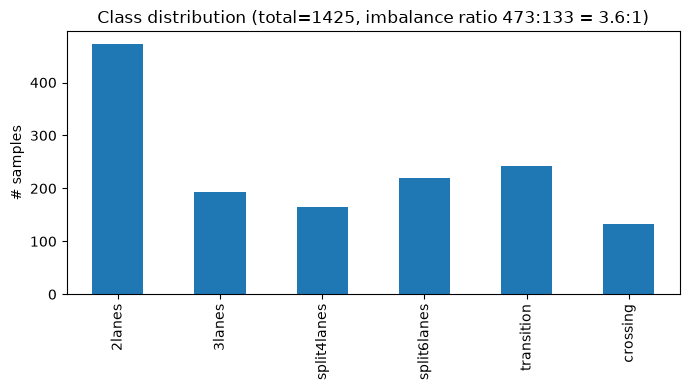

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
counts.plot.bar(ax=ax)
ax.set_ylabel("# samples")
imbalance_ratio = counts.max() / counts.min()
ax.set_title(
    f"Class distribution (total={len(samples)}, imbalance ratio "
    f"{counts.max()}:{counts.min()} = {imbalance_ratio:.1f}:1)"
)
plt.tight_layout()  # shrinks margins so the title/labels don't get clipped
plt.show()

**Observation:** `2lanes` (largest class) outnumbers `crossing` (smallest class) by
roughly 3.6:1. This single number has two concrete consequences later in the project:

- **Splitting:** a plain random 80/15/5 split could, by bad luck, put too few
  `crossing` examples in the test set. Section 4 uses a **stratified** split instead,
  which forces each split to keep the same class proportions as the full dataset.
- **Evaluation & training (M2/M4):** overall accuracy can look good while the model
  just ignores small classes. We'll need per-class metrics (precision/recall per
  class, or a confusion matrix), and may need class weighting or balanced
  subsampling when training.

## 2. Per-feature statistics per class

Each `.npy` file is a 2D array shaped `(N_points, 22)`: one row per LiDAR point, one
column per feature (`local_x`, `intensity`, `planarity`, ...). `N_points` differs
between tiles — a wide 6-lane road block has more points than a narrow 2-lane one —
so we can't just stack all tiles into one clean 3D array. Instead, for each class we
concatenate every tile's points into one big `(N_points_total_in_class, 22)` array,
i.e. we throw away which tile each point came from and just look at "all points that
belong to a `3lanes` tile", etc.

This means the statistics below are **per point**, not per tile — we're asking "what
intensity values show up across all 3lanes points?", not "what's the average
intensity of a 3lanes tile". Aggregating per *tile* (e.g. one mean-intensity number
per sample) is exactly the feature-engineering work planned for M2 — here we just
want to see the raw material before deciding how to summarise it.

In [ ]:
def class_points(class_name, samples):
    """Load and stack every point from every tile belonging to one class."""
    # Keep only the file paths whose class matches the one we're asked for.
    paths = [p for p, c, _ in samples if c == class_name]

    # load_points() calls np.load(path) under the hood — that's the one place that
    # actually touches disk. `np.concatenate(..., axis=0)` stacks the resulting 2D
    # arrays on top of each other (row-wise), since they all share the same 22
    # columns but each has a different number of rows (points).
    return np.concatenate([load_points(p) for p in paths], axis=0)

# Build one DataFrame of point-level stats per class. A DataFrame just pairs the raw
# numpy array with column names (FEATURE_NAMES), so `df["intensity"]` is readable
# instead of having to remember "intensity is column 9".
stats_per_class = {}
for class_name in CLASSES:
    pts = class_points(class_name, samples)
    df = pd.DataFrame(pts, columns=FEATURE_NAMES)

    # .describe() computes count/mean/std/min/25%/50%/75%/max for every column.
    # `.T` (transpose) flips rows and columns so features become rows and stats
    # become columns — easier to read when there are 22 features.
    stats_per_class[class_name] = df.describe().T[["mean", "std", "min", "max"]]

print("computed stats for:", list(stats_per_class.keys()))
print()
print("stats table for one class, as an example (3lanes):")
stats_per_class["3lanes"]

The project brief flags **intensity** (how strongly a laser pulse reflected off a
surface — asphalt, paint, grass, etc. all reflect differently) as one of the most
informative features besides pure geometry. Let's compare it across all 6 classes
side by side.

`pd.concat({...}, axis=1)` glues together a dict of Series into one DataFrame, using
the dict keys (`c` = class name) as column names; `.T` then flips it so each class is
a row instead of a column, which reads more naturally as a comparison table.

In [ ]:
pd.concat(
    {c: stats_per_class[c].loc["intensity"] for c in CLASSES}, axis=1
).T

Now the same idea but for *every* feature at once, keeping only the `mean` (to keep
the table a manageable size). This is a quick way to scan for features whose average
value clearly shifts between classes — those are candidates worth engineering into
per-tile summary features in M2 (e.g. `linearity` and `planarity` differ noticeably
between `2lanes`/`3lanes` and the split/crossing classes).

In [ ]:
means = pd.DataFrame({c: stats_per_class[c]["mean"] for c in CLASSES})
means

## 3. Bird's-eye-view (BEV) + intensity overlay

Per `CLAUDE.md`, every tile is **pre-aligned**: the driving direction runs along the
local y-axis, and ground points have already been filtered out before the array was
saved. That means we can get an informal top-down view of a road block for free by
scatter-plotting `local_x` against `local_y` — no rotation or projection math needed.
Colouring each point by its `intensity` value adds a hint of what's actually painted
or built on the road surface (lane markings tend to reflect differently than plain
asphalt).

This is "informal" because we're just drawing raw scattered points; M3 turns the same
idea into a proper occupancy grid (a fixed-resolution 2D image), which is what a CNN
needs as input.

In [ ]:
def plot_bev(points, ax, title=""):
    """Scatter-plot one tile's points as seen from above, coloured by intensity."""
    # Columns are fixed by FEATURE_NAMES: 0=local_x, 1=local_y, 9=intensity.
    # We could write FEATURE_NAMES.index("intensity") instead of the literal 9 to be
    # extra explicit — both give the same answer since the column order is frozen.
    x, y, intensity = points[:, 0], points[:, 1], points[:, 9]

    sc = ax.scatter(x, y, c=intensity, s=2, cmap="viridis")  # s=2 -> small dots
    ax.set_aspect("equal")  # so a square road block doesn't look stretched
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])  # axis ticks aren't meaningful here, hide them
    return sc  # returned so we can attach one shared colourbar for the whole figure

n_examples = 3  # how many example tiles to show per class

# subplots(rows, cols) builds a grid of Axes objects to draw into; here rows=classes,
# cols=examples-per-class, so we get a 6x3 grid of small BEV plots.
fig, axes = plt.subplots(
    len(CLASSES), n_examples, figsize=(3 * n_examples, 3 * len(CLASSES))
)
for row, class_name in enumerate(CLASSES):
    # Take just the first n_examples file paths for this class.
    paths = [p for p, c, _ in samples if c == class_name][:n_examples]
    for col, path in enumerate(paths):
        pts = load_points(path)
        sc = plot_bev(pts, axes[row, col], title=f"{class_name}\n{path.split('/')[-1]}")
    axes[row, 0].set_ylabel(class_name, fontsize=10)

# One shared colourbar for the whole grid, rather than one per subplot.
fig.colorbar(sc, ax=axes, label="intensity", shrink=0.5)
plt.show()

**Observation:** lane count shows up as how wide the point cloud spreads along local
x (more lanes = wider road = wider scatter). `transition` and `crossing` tiles
additionally show non-uniform width or branching along y (the road's shape changes
partway through the tile) — that's geometric structure a plain 1D feature vector (M2)
or a BEV occupancy grid (M3) should both be able to pick up on, just represented
differently.

## 4. Frozen train/val/test split

Splitting data for a supervised learning project has one hard rule: **the test set
must never influence any decision** (model choice, hyperparameters, feature
engineering) before the very final evaluation — otherwise your test accuracy is
optimistic and won't hold up on truly unseen data. The standard fix is to freeze the
split once, at the start, and reuse the exact same files as "test" for every
milestone from here on.

`get_splits()` in `src/data.py` implements that:

- The **first** time it's called (ever, project-wide), it builds an 80/15/5
  train/val/test split and writes it to `splits.json` in the project root.
- **Every later call** (this notebook, M2, M3, ...) just reads `splits.json` back —
  so as long as that file exists and is committed, everyone gets the identical split.

It uses scikit-learn's `train_test_split` with `stratify=labels`, which means: rather
than shuffling all 1425 samples together and cutting at 80%/15%/5% (which could, by
chance, put disproportionately many/few samples of a rare class like `crossing` into
one split), it splits **within each class** at those ratios and then combines the
results. Since `train_test_split` only splits into two groups at a time, `src/data.py`
calls it twice: first train vs. (val+test), then val vs. test out of that remainder.

In [ ]:
splits = get_splits()
for name, split in splits.items():
    print(f"{name}: {len(split)} samples")

Sanity check: because the split is *stratified*, each class should show up in
train/val/test in roughly the same proportion as in the full dataset (~80/15/5 each),
not just overall. Let's verify that directly instead of taking the docstring's word
for it.

In [ ]:
for name, split in splits.items():
    split_classes = [c for _, c, _ in split]
    split_counts = pd.Series(split_classes).value_counts().reindex(CLASSES)
    print(f"--- {name} ({len(split)} total) ---")
    print((split_counts / counts * 100).round(1).astype(str) + "%")
    print()

**Takeaway:** every class keeps roughly the same 80/15/5 split ratio it has overall
(small rounding differences are expected — you can't split 133 `crossing` samples into
an exact 80/15/5 without a remainder). From here on, `splits.json` is committed and
frozen: M2's baseline model, M3's CNN, and any later milestone should all call
`get_splits()` and get back these exact same files, and none of them should ever peek
at, tune against, or retrain on the `test` split until the final evaluation.